In [2]:
# ==========================================
# FASE 3. VISUALIZACIÓN DE DATOS
# ==========================================

# Importación de librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [3]:
# Cargamos el dataset limpio

df = pd.read_csv("files/hr_limpio.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


In [4]:
# Creamos dos DataFrames para facilitar algunas visualizaciones

df_se_quedan = df[df["Attrition"] == "No"]

df_se_van = df[df["Attrition"] == "Yes"]

In [5]:
df["Attrition_text"] = df["Attrition"].map({
    "Yes": "Se va",
    "No": "Se queda"
})

In [6]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_text
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5,Se va
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7,Se queda
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0,Se va
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0,Se queda
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2,Se queda


In [7]:
print(f"""
Tenemos información de {df.shape[0]} empleados.

A continuación observamos cuántos empleados continúan en la empresa
y cuántos han abandonado la organización.
""")

df["Attrition_text"].value_counts()


Tenemos información de 1470 empleados.

A continuación observamos cuántos empleados continúan en la empresa
y cuántos han abandonado la organización.



Attrition_text
Se queda    1233
Se va        237
Name: count, dtype: int64

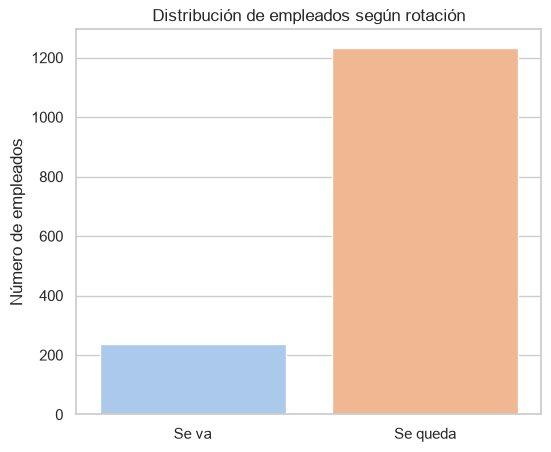

In [8]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Attrition_text",
    palette="pastel"
)

plt.title("Distribución de empleados según rotación")
plt.xlabel("")
plt.ylabel("Número de empleados")

plt.show()

1. Contextualización de la empresa

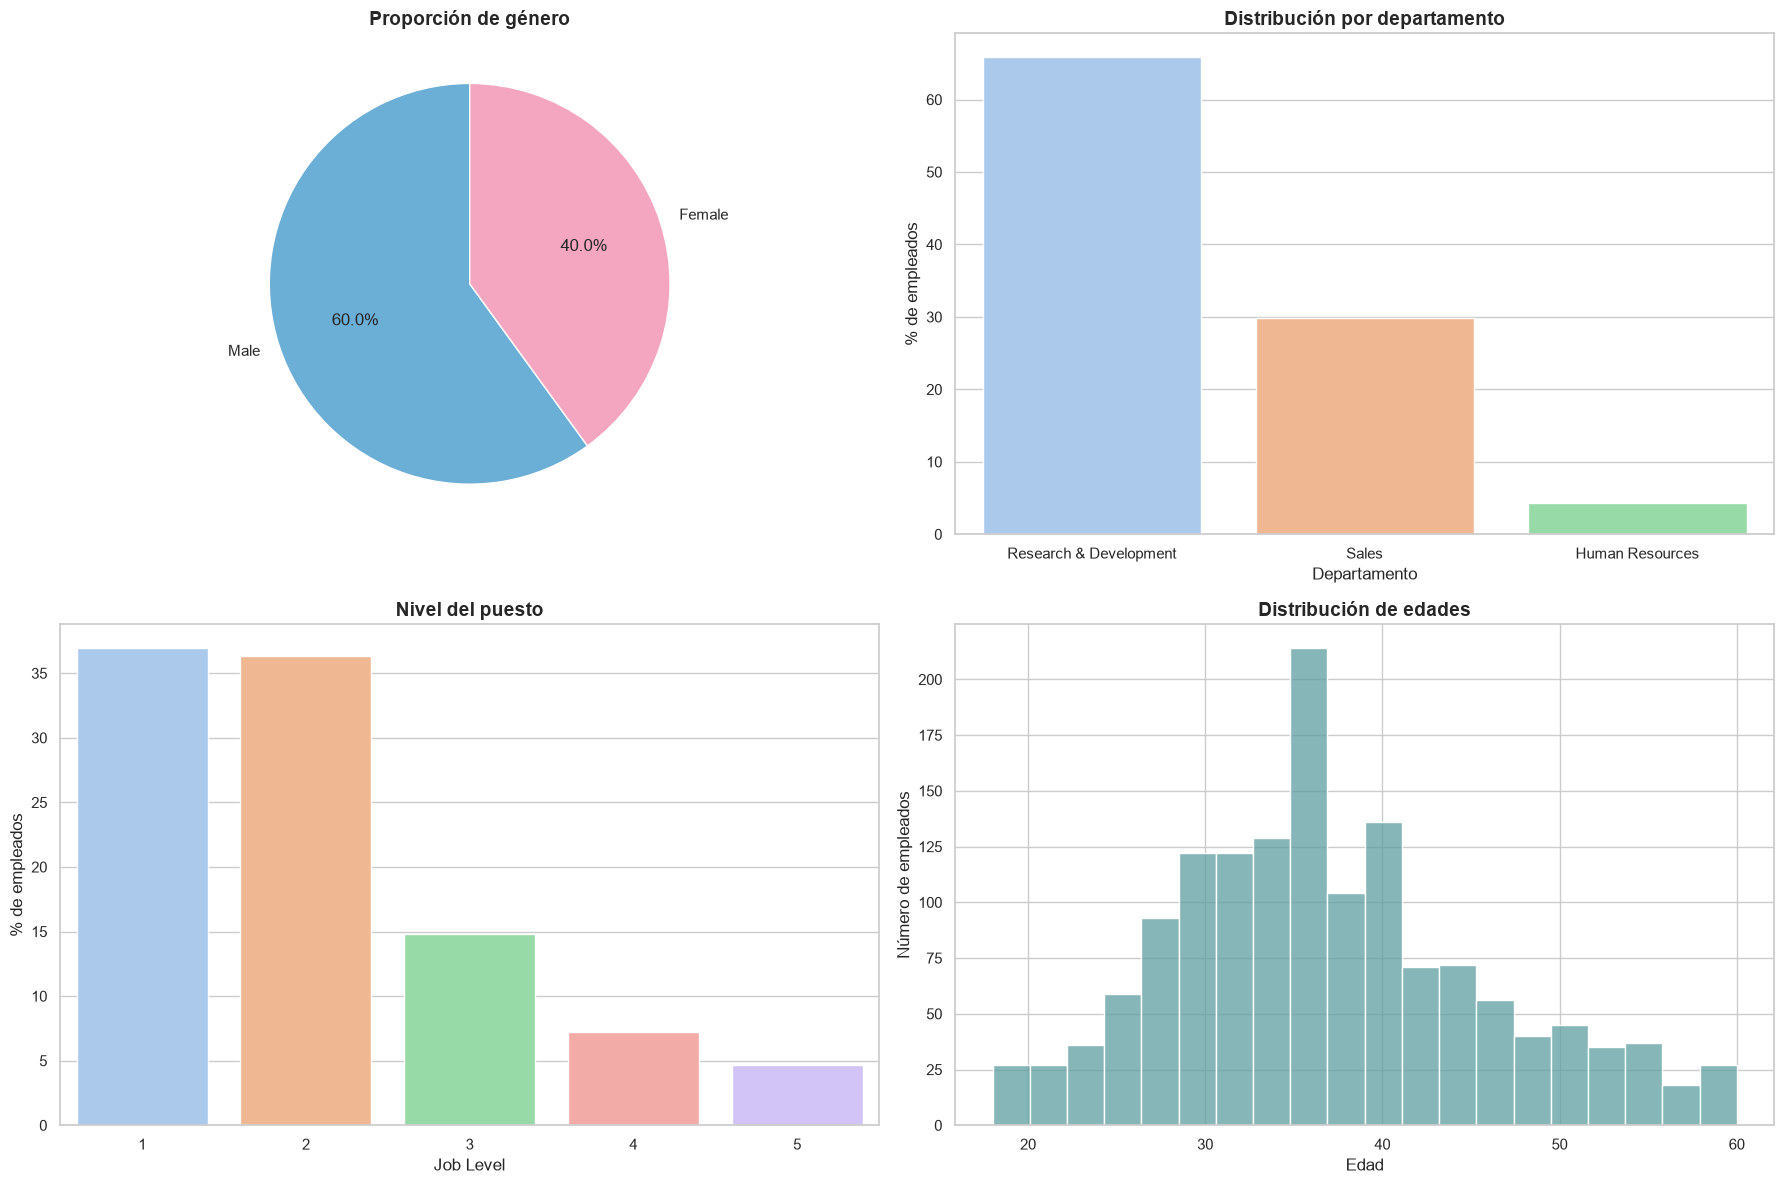

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18,12))

# -------------------------------------------------------
# 1. Proporción de género
# -------------------------------------------------------

conteo_genero = df["Gender"].value_counts()

axes[0,0].pie(
    conteo_genero,
    labels=conteo_genero.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#6baed6", "#f4a6c1"],
    wedgeprops={"edgecolor":"white"}
)

axes[0,0].set_title(
    "Proporción de género",
    fontsize=14,
    fontweight="bold"
)


# -------------------------------------------------------
# 2. Distribución por departamento
# -------------------------------------------------------

departamentos = df["Department"].value_counts().index

sns.countplot(
    data=df,
    x="Department",
    order=departamentos,
    stat="percent",
    palette="pastel",
    ax=axes[0,1]
)

axes[0,1].set_title(
    "Distribución por departamento",
    fontsize=14,
    fontweight="bold"
)

axes[0,1].set_xlabel("Departamento")
axes[0,1].set_ylabel("% de empleados")


# -------------------------------------------------------
# 3. Nivel del puesto
# -------------------------------------------------------

sns.countplot(
    data=df,
    x="JobLevel",
    stat="percent",
    palette="pastel",
    ax=axes[1,0]
)

axes[1,0].set_title(
    "Nivel del puesto",
    fontsize=14,
    fontweight="bold"
)

axes[1,0].set_xlabel("Job Level")
axes[1,0].set_ylabel("% de empleados")


# -------------------------------------------------------
# 4. Distribución de edades
# -------------------------------------------------------

sns.histplot(
    data=df,
    x="Age",
    bins=20,
    color="cadetblue",
    ax=axes[1,1]
)

axes[1,1].set_title(
    "Distribución de edades",
    fontsize=14,
    fontweight="bold"
)

axes[1,1].set_xlabel("Edad")
axes[1,1].set_ylabel("Número de empleados")


plt.tight_layout()

plt.show()

Análisis:

Estos gráficos ofrecen una visión general de la plantilla de la empresa antes de estudiar la rotación. Se observa una mayor presencia de empleados en el departamento de Research & Development, seguido de Sales, mientras que Human Resources representa una proporción mucho menor. La distribución por niveles de puesto muestra que la mayoría de los empleados ocupan los niveles inferiores (JobLevel 1 y 2), lo que indica una estructura organizativa con una base amplia y menos posiciones de alta responsabilidad. Respecto a la edad, la plantilla se concentra principalmente entre los 30 y 40 años, con pocos empleados muy jóvenes o cercanos a la jubilación. Finalmente, la distribución por género muestra una mayor representación masculina (60%) frente a femenina (40%), aunque ambos grupos cuentan con una presencia significativa para posteriores comparaciones sobre la rotación.

2.  ¿Cuál es la rotación de empleados en la empresa?

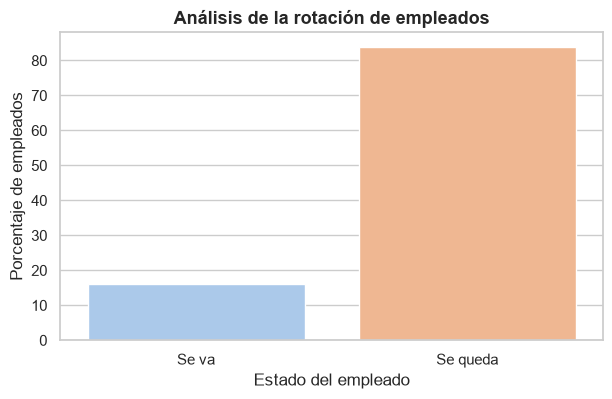

In [ ]:

plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="Attrition_text",
    stat="percent",
    palette="pastel"
)

plt.title(
    "Análisis de la rotación de empleados",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Estado del empleado")
plt.ylabel("Porcentaje de empleados")

plt.show()

In [11]:
# Porcentaje de empleados que permanecen y abandonan la empresa

round(df["Attrition_text"].value_counts(normalize=True)*100,2)

Attrition_text
Se queda    83.88
Se va       16.12
Name: proportion, dtype: float64

Análisis

En este primer análisis observamos la distribución de empleados que permanecen en la empresa frente a aquellos que la han abandonado. Aproximadamente el 84 % de los empleados continúa trabajando en la organización, mientras que cerca del 16 % ha causado baja.

Aunque la mayoría de la plantilla permanece en la empresa, el porcentaje de rotación no es despreciable y justifica realizar un análisis más profundo. A partir de este punto, el objetivo será identificar qué características personales y laborales están más asociadas con el abandono de la empresa para detectar posibles factores de riesgo y facilitar la toma de decisiones en el área de Recursos Humanos.

3. Antigüedad en la empresa según rotación

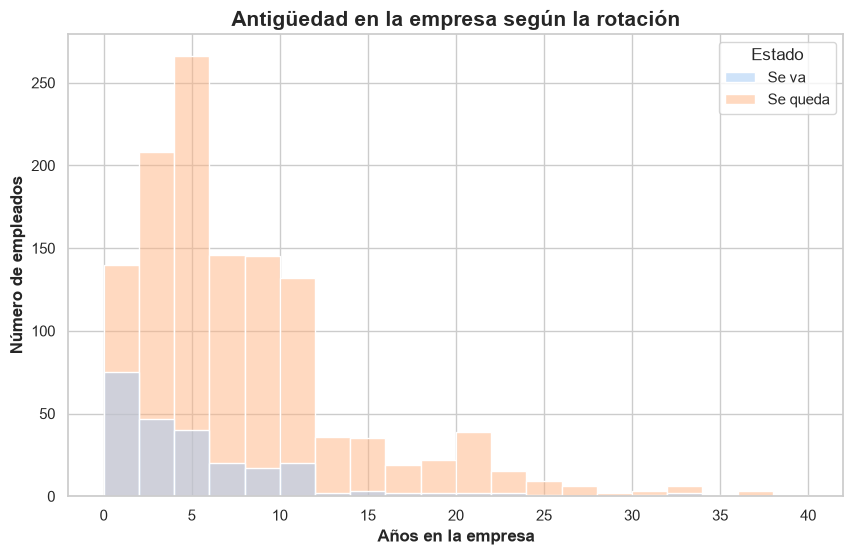

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.histplot(
    data=df,
    x="YearsAtCompany",
    hue="Attrition_text",
    bins=20,
    palette="pastel"
)

plt.title(
    "Antigüedad en la empresa según la rotación",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Años en la empresa",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Número de empleados",
    fontsize=12,
    fontweight="bold"
)

sns.move_legend(
    ax,
    "upper right",
    title="Estado"
)

plt.show()

Análisis

La mayor concentración de empleados se encuentra durante los primeros años de permanencia en la empresa, especialmente entre 0 y 10 años de antigüedad. También es en este intervalo donde se observa el mayor número de empleados que abandonan la organización.

A medida que aumenta la antigüedad, el número de bajas disminuye considerablemente, lo que sugiere que los empleados con más años en la empresa presentan una mayor estabilidad laboral y una menor probabilidad de abandonar la organización.

Estos resultados indican que los primeros años son una etapa especialmente relevante para la retención del talento. Por ello, podría ser recomendable reforzar las estrategias de integración, formación y desarrollo profesional dirigidas a los empleados de reciente incorporación.

In [14]:
# Mediana de años en la empresa según el estado del empleado

df.groupby("Attrition_text")["YearsAtCompany"].median()

Attrition_text
Se queda    6.0
Se va       3.0
Name: YearsAtCompany, dtype: float64

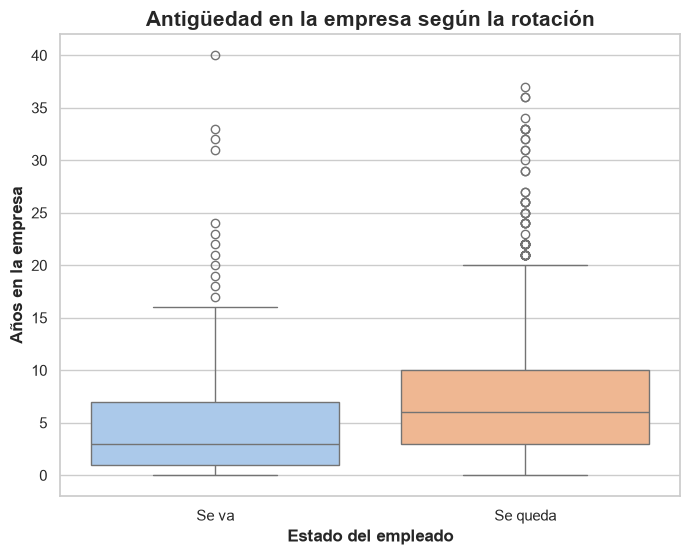

In [13]:
# ==========================================
# Comparación de la antigüedad según la rotación
# ==========================================

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Attrition_text",
    y="YearsAtCompany",
    palette="pastel"
)

plt.title(
    "Antigüedad en la empresa según la rotación",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Estado del empleado",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Años en la empresa",
    fontsize=12,
    fontweight="bold"
)

plt.show()

Análisis

Tanto el histograma como el boxplot muestran que la rotación se concentra en los primeros años de permanencia en la empresa. La mediana de antigüedad de los empleados que abandonan la organización es de 3 años, mientras que en los empleados que permanecen asciende a 6 años.

Esto indica que quienes dejan la empresa suelen hacerlo en una fase relativamente temprana de su trayectoria profesional. En cambio, los empleados que superan los primeros años tienden a consolidarse dentro de la organización y presentan una mayor estabilidad laboral.

Estos resultados sugieren que las estrategias de retención deberían centrarse especialmente en los empleados de reciente incorporación, reforzando aspectos como el proceso de onboarding, el desarrollo profesional y el seguimiento durante los primeros años en la empresa.

4. El factor económico: Salario mensual y rotación
4.1 Comparación mediante boxplot

Attrition_text
Se queda    6815.33
Se va       4757.28
Name: MonthlyIncome, dtype: float64
Attrition_text
Se queda    5155.0
Se va       3348.0
Name: MonthlyIncome, dtype: float64


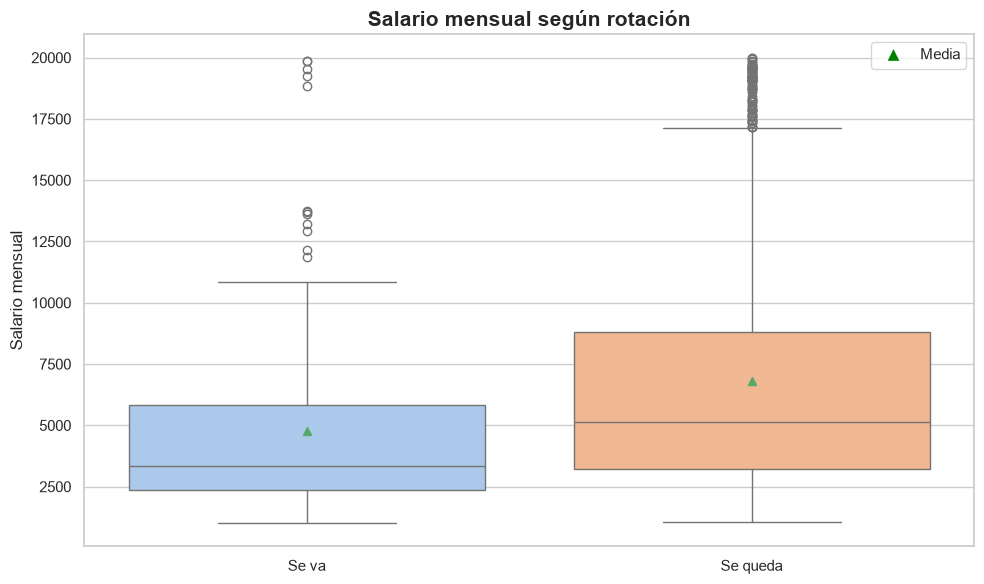

In [21]:
from matplotlib.lines import Line2D

# Media y mediana por grupo
print(df.groupby("Attrition_text")["MonthlyIncome"].mean().round(2))
print(df.groupby("Attrition_text")["MonthlyIncome"].median())

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Attrition_text",
    y="MonthlyIncome",
    hue="Attrition_text",
    palette="pastel",
    showmeans=True,
    legend=False
)

plt.title("Salario mensual según rotación", fontsize=15, fontweight="bold")
plt.xlabel("")
plt.ylabel("Salario mensual")

mean_handle = Line2D([0],[0],
                     marker="^",
                     color="white",
                     markerfacecolor="green",
                     markersize=10,
                     label="Media")

plt.legend(handles=[mean_handle], loc="upper right")

plt.tight_layout()
plt.show()

Análisis

Existe una diferencia salarial clara entre ambos grupos. Los empleados que abandonan la empresa presentan un salario medio de 4.757, frente a los 6.815 de quienes permanecen en ella.

La mediana también refleja esta diferencia (3.348 frente a 5.155), indicando que la mayor parte de los empleados que abandonan la empresa pertenece a los niveles salariales más bajos.

Aunque existen algunos empleados con salarios elevados que también abandonan la organización, el salario parece ser un factor asociado a una mayor probabilidad de rotación.

4.2 Histograma

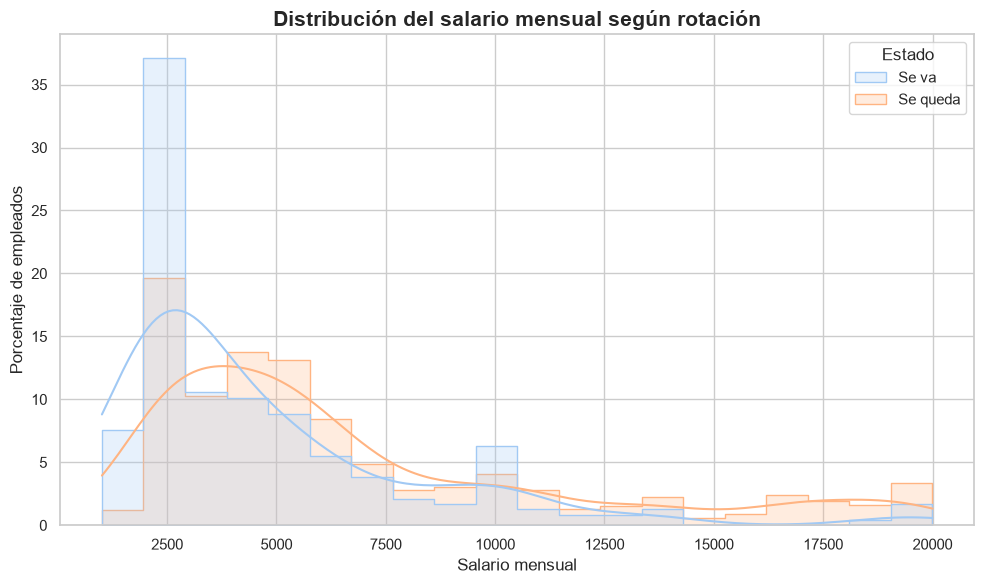

In [22]:
plt.figure(figsize=(10,6))

ax = sns.histplot(
    data=df,
    x="MonthlyIncome",
    hue="Attrition_text",
    bins=20,
    stat="percent",
    common_norm=False,
    kde=True,
    element="step",
    palette="pastel",
    hue_order=["Se va","Se queda"]
)

plt.title("Distribución del salario mensual según rotación",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Salario mensual")
plt.ylabel("Porcentaje de empleados")

sns.move_legend(ax, "upper right", title="Estado")

plt.tight_layout()
plt.show()

Análisis

El histograma confirma el resultado observado en el boxplot. La mayor concentración de empleados que abandonan la empresa se sitúa en los rangos salariales más bajos, mientras que los empleados que permanecen presentan una distribución más amplia y una mayor presencia en los salarios altos.

A medida que aumenta el salario mensual, disminuye la proporción de empleados que abandonan la empresa, lo que sugiere que una remuneración más elevada puede estar relacionada con una mayor retención del talento.

5. ¿Dónde existe menor satisfacción laboral?

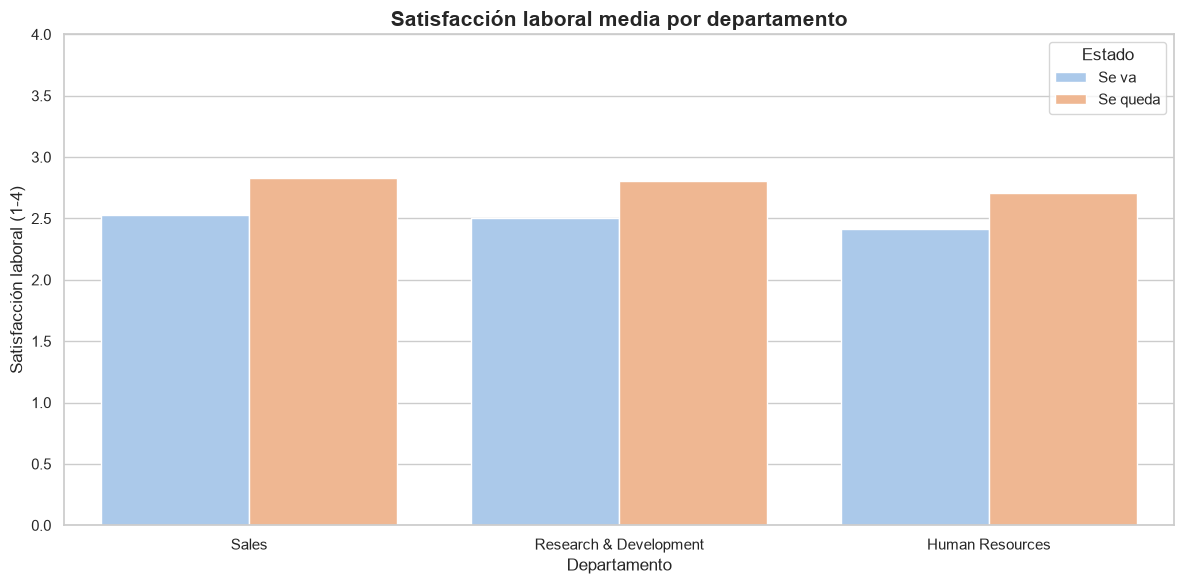

In [23]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="Department",
    y="JobSatisfaction",
    hue="Attrition_text",
    palette="pastel",
    errorbar=None,
    hue_order=["Se va", "Se queda"]
)

plt.title("Satisfacción laboral media por departamento",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Departamento")
plt.ylabel("Satisfacción laboral (1-4)")
plt.ylim(0,4)

plt.legend(title="Estado")

plt.tight_layout()
plt.show()

In [24]:
df.groupby(["Department","Attrition_text"])["JobSatisfaction"].mean().round(2)

Department              Attrition_text
Human Resources         Se queda          2.71
                        Se va             2.42
Research & Development  Se queda          2.80
                        Se va             2.50
Sales                   Se queda          2.83
                        Se va             2.53
Name: JobSatisfaction, dtype: float64

Interpretación

La satisfacción laboral es sistemáticamente mayor entre los empleados que permanecen en la empresa que entre aquellos que la abandonan, independientemente del departamento.

Human Resources: 2,71 (se quedan) vs 2,42 (se van).
Research & Development: 2,80 vs 2,50.
Sales: 2,83 vs 2,53.

Aunque las diferencias no son muy grandes (alrededor de 0,3 puntos en una escala de 1 a 4), el patrón se repite en los tres departamentos. Esto sugiere que una menor satisfacción laboral está asociada con una mayor probabilidad de rotación.

Además, los niveles medios de satisfacción son relativamente similares entre departamentos, por lo que la fuga de talento parece estar más relacionada con la experiencia individual del empleado que con el departamento al que pertenece.

💡 Conclusión clave: La satisfacción laboral no explica qué departamento pierde más empleados, pero sí diferencia claramente a quienes permanecen de quienes abandonan la empresa.

6. ¿Qué puestos de trabajo presentan mayor porcentaje de abandono?

In [45]:
# Tabla con el porcentaje de empleados por puesto y estado
tabla_jobrole = (
    pd.crosstab(
        df["JobRole"],
        df["Attrition_text"],
        normalize="index"
    ) * 100
).reset_index()

# Nos quedamos solo con el porcentaje de empleados que se van
tabla_jobrole = tabla_jobrole.sort_values(by="Se va", ascending=False)

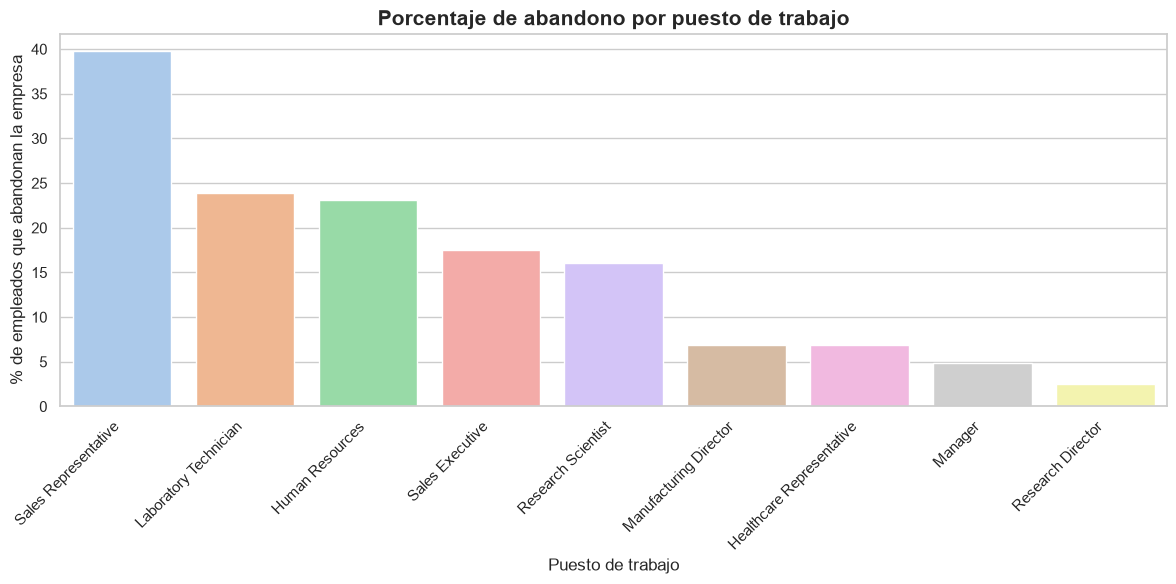

In [46]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=tabla_jobrole,
    x="JobRole",
    y="Se va",
    palette="pastel"
)

plt.title("Porcentaje de abandono por puesto de trabajo",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Puesto de trabajo")
plt.ylabel("% de empleados que abandonan la empresa")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Interpretación
El porcentaje de abandono no es igual en todos los puestos de trabajo. Algunos cargos, como sales representative, presentan una tasa de rotación claramente superior, prácticamente el doble que en otros puestos, lo que indica que determinados perfiles son más difíciles de retener. Este análisis permite identificar los puestos con mayor riesgo de fuga de talento y priorizar acciones específicas de retención, como planes de carrera, revisiones salariales o programas de desarrollo profesional.

7. ¿Es la rotación mayor en los niveles de entrada?

Attrition_text  Se queda  Se va
JobLevel                       
1                  73.66  26.34
2                  90.26   9.74
3                  85.32  14.68
4                  95.28   4.72
5                  92.75   7.25


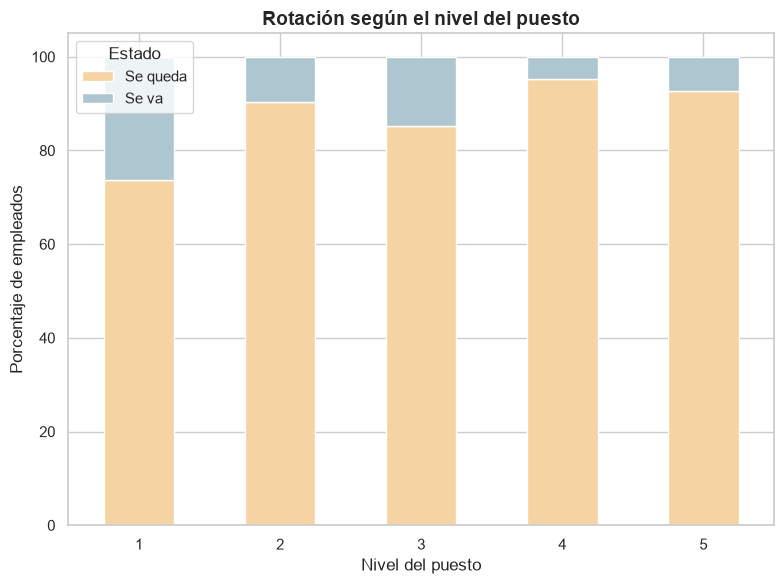

In [49]:
# Tabla en porcentaje
tabla_joblevel = pd.crosstab(
    df["JobLevel"],
    df["Attrition_text"],
    normalize="index"
) * 100

print(tabla_joblevel.round(2))

# Gráfico
colores = {"Se va": "#AEC6CF", "Se queda": "#F5D3A3"}

tabla_joblevel.plot(
    kind="bar",
    stacked=True,
    figsize=(8,6),
    color=colores
)

plt.title("Rotación según el nivel del puesto", fontsize=14, fontweight="bold")
plt.xlabel("Nivel del puesto")
plt.ylabel("Porcentaje de empleados")
plt.xticks(rotation=0)
plt.legend(title="Estado")
plt.tight_layout()
plt.show()

In [50]:
tabla_joblevel.round(2)

Attrition_text,Se queda,Se va
JobLevel,,
1,73.66,26.34
2,90.26,9.74
3,85.32,14.68
4,95.28,4.72
5,92.75,7.25


Interpretación 
La rotación es significativamente mayor en los empleados con Job Level 1, donde aproximadamente el 26,3% de los trabajadores abandona la empresa. A partir del nivel 2, la tasa de rotación disminuye considerablemente, situándose entre el 5% y el 15%, siendo el nivel 4 el que presenta la menor proporción de abandonos (4,7%). Esto sugiere que los empleados en puestos de entrada son los más propensos a abandonar la organización, posiblemente por contar con menos estabilidad, menor experiencia o mayores oportunidades de crecimiento en otras empresas. Estos resultados refuerzan los análisis anteriores sobre salario, edad y antigüedad, que también indicaban que la fuga de talento se concentra principalmente en los perfiles más junior.

8. ¿A qué edad abandonan la empresa los empleados?

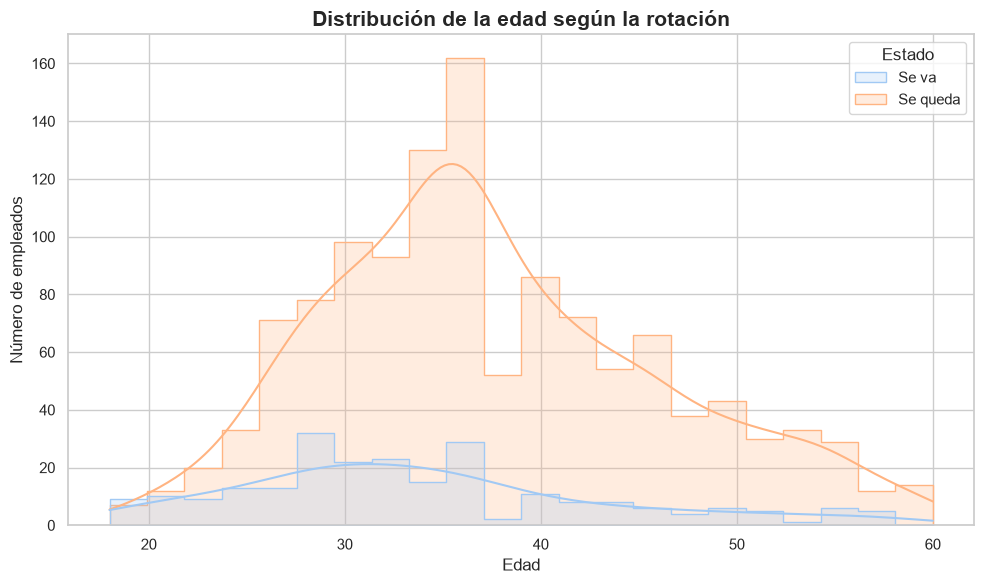

In [25]:
plt.figure(figsize=(10,6))

ax = sns.histplot(
    data=df,
    x="Age",
    hue="Attrition_text",
    kde=True,
    palette="pastel",
    element="step",
    hue_order=["Se va", "Se queda"]
)

plt.title("Distribución de la edad según la rotación",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Edad")
plt.ylabel("Número de empleados")

sns.move_legend(ax, "upper right", title="Estado")

plt.tight_layout()
plt.show()

In [26]:
print(df.groupby("Attrition_text")["Age"].mean().round(1))
print(df.groupby("Attrition_text")["Age"].median())

Attrition_text
Se queda    37.5
Se va       33.8
Name: Age, dtype: float64
Attrition_text
Se queda    36.0
Se va       32.0
Name: Age, dtype: float64


Interpretación

La edad parece estar relacionada con la rotación de empleados. Quienes abandonan la empresa tienen una edad media de 33,8 años, frente a los 37,5 años de quienes permanecen en ella. La mediana muestra el mismo patrón (32 años frente a 36 años), lo que confirma que las salidas se concentran en empleados relativamente más jóvenes.

En el histograma se observa que la mayor concentración de abandonos se sitúa entre los 25 y 35 años, mientras que a partir de los 40 años la frecuencia de salidas disminuye de forma notable. Esto sugiere que los empleados con mayor experiencia presentan una mayor estabilidad laboral, mientras que los perfiles más jóvenes podrían mostrar una mayor movilidad o estar buscando oportunidades de crecimiento profesional.

💡 Conclusión clave: La empresa retiene mejor a los empleados de mayor edad, mientras que la rotación se concentra en los perfiles más jóvenes. Esto sugiere que las estrategias de fidelización deberían centrarse especialmente en los primeros años de la carrera profesional, ofreciendo planes de desarrollo, formación y oportunidades de crecimiento.

9. ¿Influye la distancia al trabajo en la rotación?

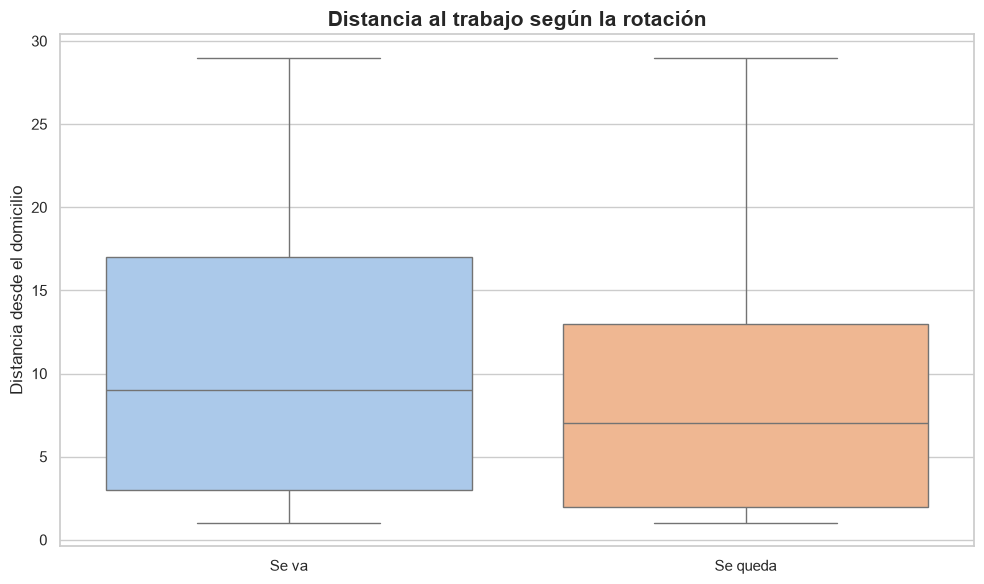

In [27]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Attrition_text",
    y="DistanceFromHome",
    hue="Attrition_text",
    palette="pastel",
    legend=False
)

plt.title("Distancia al trabajo según la rotación",
          fontsize=15,
          fontweight="bold")

plt.xlabel("")
plt.ylabel("Distancia desde el domicilio")

plt.tight_layout()
plt.show()

In [28]:
print(df.groupby("Attrition_text")["DistanceFromHome"].mean().round(2))
print(df.groupby("Attrition_text")["DistanceFromHome"].median())

Attrition_text
Se queda     8.92
Se va       10.63
Name: DistanceFromHome, dtype: float64
Attrition_text
Se queda    7.0
Se va       9.0
Name: DistanceFromHome, dtype: float64


Interpretación

Los empleados que abandonan la empresa viven, de media, más lejos de su lugar de trabajo que quienes permanecen en ella. La distancia media es de 10,63 km para los empleados que se marchan, frente a 8,92 km para los que continúan en la empresa. La mediana refleja el mismo patrón (9 km frente a 7 km).

Aunque existe un amplio solapamiento entre ambos grupos, estos resultados sugieren que una mayor distancia al centro de trabajo podría estar asociada con una mayor probabilidad de rotación. No obstante, por sí sola no parece explicar completamente el abandono de la empresa y debería analizarse junto con otros factores como el salario, la satisfacción laboral o las horas extra.

💡 Conclusión clave: La distancia al trabajo parece influir ligeramente en la rotación, pero su efecto es mucho menor que el observado para variables como el salario o la satisfacción laboral. Políticas de flexibilidad, como el teletrabajo o los modelos híbridos, podrían contribuir a mejorar la retención de empleados que residen más lejos.

10. ¿Influye el estado civil en la rotación?

Attrition_text  Se queda  Se va
MaritalStatus                  
Divorced           89.19  10.81
Married            87.40  12.60
Single             74.31  25.69


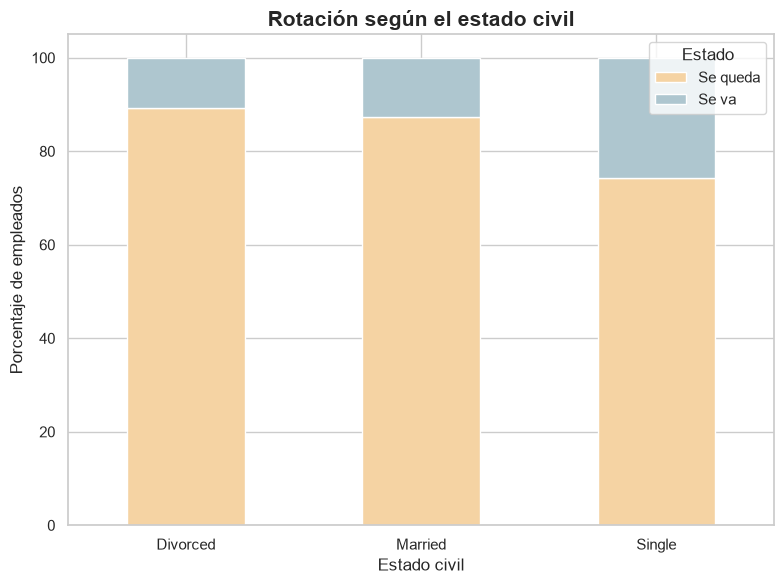

Attrition_text,Se queda,Se va
MaritalStatus,,
Divorced,89.19,10.81
Married,87.40,12.60
Single,74.31,25.69


In [ ]:
# Parte 1. Estado civil y rotación
# Tabla cruzada en porcentaje
tabla_marital = pd.crosstab(
    df["MaritalStatus"],
    df["Attrition_text"],
    normalize="index"
) * 100

print(tabla_marital.round(2))

# Gráfico
colores = {"Se va": "#AEC6CF", "Se queda": "#F5D3A3"}

tabla_marital.plot(
    kind="bar",
    stacked=True,
    figsize=(8,6),
    color=colores
)

plt.title("Rotación según el estado civil",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Estado civil")
plt.ylabel("Porcentaje de empleados")

plt.xticks(rotation=0)
plt.legend(title="Estado")

plt.tight_layout()
plt.show()



Interpretación
El estado civil parece estar relacionado con la rotación de empleados. Los trabajadores solteros presentan la tasa de abandono más elevada, con un 25,7%, aproximadamente el doble que los empleados casados (12,6%) y más del doble que los divorciados (10,8%). Esto sugiere que los empleados solteros muestran una mayor movilidad laboral o una menor vinculación con la empresa, mientras que los casados y divorciados presentan una mayor estabilidad. No obstante, el estado civil por sí solo no explica la rotación, por lo que conviene analizarlo junto a otros factores como las horas extra o la frecuencia de los viajes de trabajo.

OverTime          No    Yes
MaritalStatus              
Divorced       70.27  29.73
Married        72.76  27.24
Single         73.39  26.61


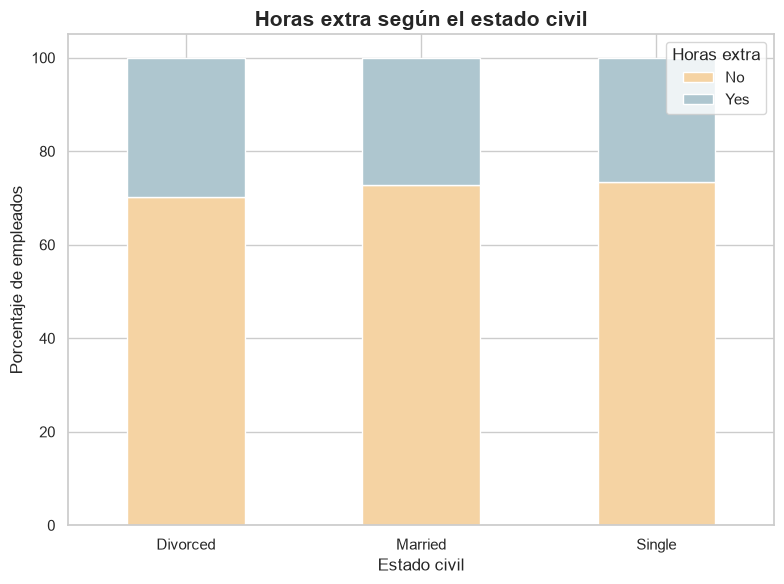

In [ ]:
# Parte 2. Estado civil, horas extra y frecuencia de viajes. Aquí queremos ver si los empleados solteros, casados o divorciados son quienes más hacen horas extra y viajan con mayor frecuencia.
# Horas extra
tabla_overtime = pd.crosstab(
    df["MaritalStatus"],
    df["OverTime"],
    normalize="index"
) * 100

print(tabla_overtime.round(2))

tabla_overtime.plot(
    kind="bar",
    stacked=True,
    figsize=(8,6),
    color=["#F5D3A3", "#AEC6CF"]
)

plt.title("Horas extra según el estado civil",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Estado civil")
plt.ylabel("Porcentaje de empleados")

plt.xticks(rotation=0)
plt.legend(title="Horas extra")

plt.tight_layout()
plt.show()

Interpretación
A diferencia de la rotación, el estado civil no parece influir en la realización de horas extra. Aproximadamente entre el 26% y el 30% de los empleados de cada grupo (solteros, casados y divorciados) realiza horas extra, mostrando diferencias muy pequeñas entre ellos. Esto indica que la mayor tasa de abandono observada en los empleados solteros no puede explicarse por una mayor carga de horas extra, por lo que es probable que intervengan otros factores, como la edad, el nivel del puesto o la frecuencia de los viajes de trabajo.

De hecho, este resultado es interesante porque desmonta una posible hipótesis: los solteros se van más, pero no porque hagan más horas extra.

BusinessTravel  Non-Travel  Travel_Frequently  Travel_Rarely
MaritalStatus                                               
Divorced             12.84              18.24          68.92
Married               8.54              17.21          74.25
Single                8.72              18.81          72.48


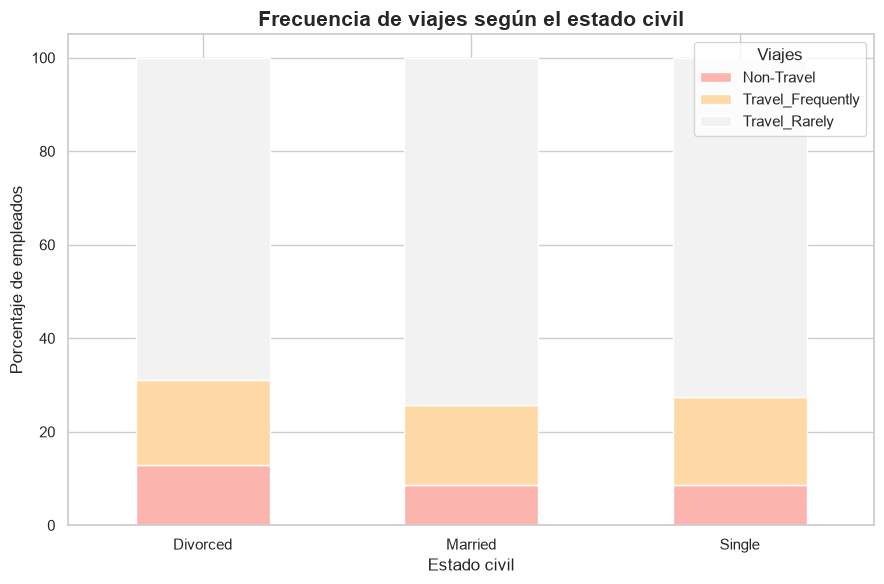

In [54]:
# Frecuencia de viajes
tabla_viajes = pd.crosstab(
    df["MaritalStatus"],
    df["BusinessTravel"],
    normalize="index"
) * 100

print(tabla_viajes.round(2))

tabla_viajes.plot(
    kind="bar",
    stacked=True,
    figsize=(9,6),
    colormap="Pastel1"
)

plt.title("Frecuencia de viajes según el estado civil",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Estado civil")
plt.ylabel("Porcentaje de empleados")

plt.xticks(rotation=0)
plt.legend(title="Viajes")

plt.tight_layout()
plt.show()

Interpretación
El análisis de la frecuencia de los viajes de trabajo muestra que el estado civil no parece influir de forma significativa. En los tres grupos predominan los empleados que viajan ocasionalmente (entre el 69% y el 74%), mientras que alrededor del 17%-19% viaja con frecuencia y menos del 13% no realiza viajes de trabajo. Estas diferencias son reducidas, por lo que la mayor tasa de rotación observada entre los empleados solteros no puede atribuirse a una mayor frecuencia de viajes. Es probable que otros factores, como la edad, el nivel del puesto o el salario, tengan un mayor peso en la decisión de abandonar la empresa.

Conclusión general

En conjunto, el estado civil muestra relación con la rotación, ya que los empleados solteros presentan una tasa de abandono significativamente superior a la de casados y divorciados. Sin embargo, esta diferencia no parece explicarse por una mayor realización de horas extra ni por una mayor frecuencia de viajes de trabajo, ya que ambos factores presentan distribuciones muy similares entre los distintos estados civiles. Esto sugiere que el estado civil actúa como un factor asociado a la rotación, pero no como su causa directa, siendo necesario considerar otras variables como la edad, la antigüedad, el salario o el nivel del puesto para comprender mejor el abandono de empleados

11. Relación entre satisfacción laboral y horas extra

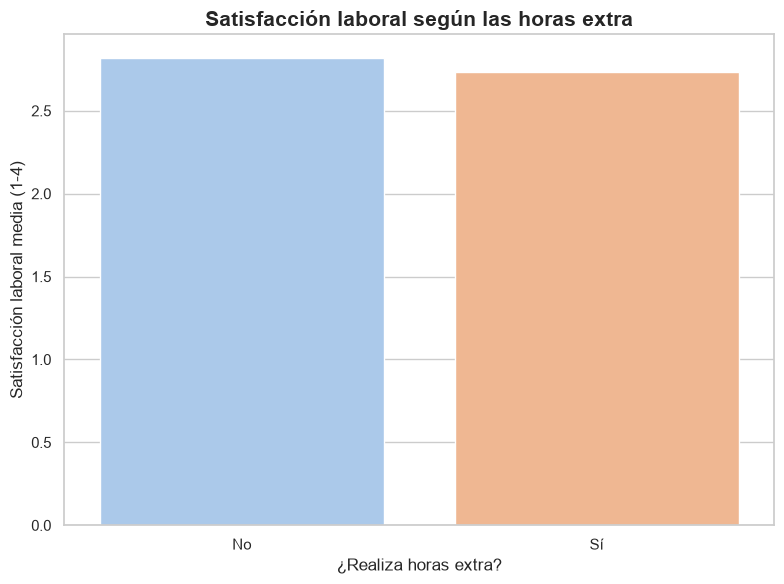

In [55]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=df,
    x="OverTime",
    y="JobSatisfaction",
    palette="pastel",
    errorbar=None
)

plt.title("Satisfacción laboral según las horas extra",
          fontsize=15,
          fontweight="bold")

plt.xlabel("¿Realiza horas extra?")
plt.ylabel("Satisfacción laboral media (1-4)")

plt.xticks([0,1], ["No", "Sí"])

plt.tight_layout()
plt.show()

In [56]:
df.groupby("OverTime")["JobSatisfaction"].mean().round(2)

OverTime
No     2.73
Yes    2.82
Name: JobSatisfaction, dtype: float64

Interpretación
Contra lo esperado, los empleados que realizan horas extra presentan una satisfacción laboral media (2,82) ligeramente superior a la de quienes no las realizan (2,73). La diferencia es muy pequeña, por lo que no parece existir una relación clara entre realizar horas extra y tener una menor satisfacción laboral. Esto sugiere que el impacto de las horas extra sobre la rotación no se explica por una disminución de la satisfacción laboral, sino probablemente por otros factores, como el desgaste acumulado, la conciliación entre la vida personal y laboral o la carga de trabajo.

12. Relación entre salario y horas extra

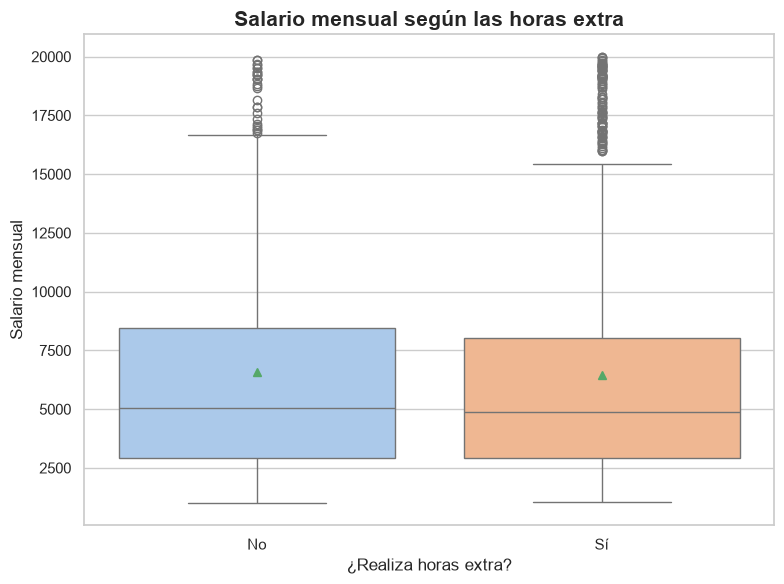

In [57]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="OverTime",
    y="MonthlyIncome",
    palette="pastel",
    showmeans=True
)

plt.title("Salario mensual según las horas extra",
          fontsize=15,
          fontweight="bold")

plt.xlabel("¿Realiza horas extra?")
plt.ylabel("Salario mensual")

plt.xticks([0,1], ["No", "Sí"])

plt.tight_layout()
plt.show()

In [58]:
print(df.groupby("OverTime")["MonthlyIncome"].mean().round(2))
print(df.groupby("OverTime")["MonthlyIncome"].median().round(2))

OverTime
No     6447.70
Yes    6577.74
Name: MonthlyIncome, dtype: float64
OverTime
No     4898.0
Yes    5056.0
Name: MonthlyIncome, dtype: float64


Interpretación
El salario mensual medio de los empleados que realizan horas extra (6.577,74) es ligeramente superior al de quienes no las realizan (6.447,70). La mediana muestra el mismo patrón (5.056 frente a 4.898), aunque la diferencia es reducida. Estos resultados indican que los empleados que hacen horas extra no reciben una compensación salarial sustancialmente mayor. Teniendo en cuenta que este grupo presenta una tasa de rotación significativamente más alta, los datos sugieren que el incremento salarial no compensa el impacto que puede tener una mayor carga de trabajo sobre la permanencia en la empresa.

En conjunto, los resultados muestran que las horas extra están claramente asociadas a una mayor rotación, pero no a una menor satisfacción laboral ni a diferencias salariales relevantes. Esto indica que el abandono de los empleados que realizan horas extra probablemente esté relacionado con otros factores, como la carga de trabajo, el desgaste o la dificultad para conciliar la vida laboral y personal, más que con el nivel de satisfacción o la compensación económica.

En resumen, las horas extra son uno de los factores más relacionados con el abandono de empleados, aunque ese efecto no parece deberse ni al salario ni a una menor satisfacción laboral.

13. ¿Qué relación existe entre género y satisfacción laboral?

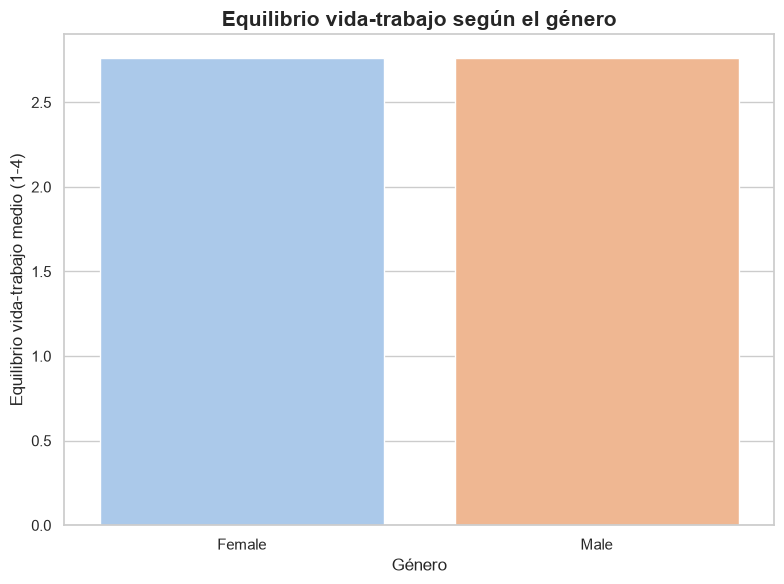

In [59]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=df,
    x="Gender",
    y="WorkLifeBalance",
    palette="pastel",
    errorbar=None
)

plt.title("Equilibrio vida-trabajo según el género",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Género")
plt.ylabel("Equilibrio vida-trabajo medio (1-4)")

plt.tight_layout()
plt.show()

In [60]:
df.groupby("Gender")["WorkLifeBalance"].mean().round(2)

Gender
Female    2.76
Male      2.76
Name: WorkLifeBalance, dtype: float64

In [61]:
tabla_balance = pd.crosstab(
    df["Gender"],
    df["WorkLifeBalance"],
    normalize="index"
) * 100

print(tabla_balance.round(2))

WorkLifeBalance     1      2      3      4
Gender                                    
Female           5.10  23.13  62.07   9.69
Male             5.67  23.58  59.86  10.88


Interpretación
Los resultados muestran una distribución muy similar del nivel de equilibrio entre la vida laboral y personal en hombres y mujeres. En ambos casos, alrededor del 60% de los empleados califica su equilibrio con un nivel 3, mientras que los niveles 1, 2 y 4 presentan porcentajes muy parecidos.

En consecuencia, el género no parece ser un factor determinante en la percepción del equilibrio entre la vida personal y laboral dentro de la empresa. Las diferencias observadas son mínimas y no sugieren un patrón relevante.

14. El impacto de las horas extra en la rotación

In [29]:
# Distribución de empleados según si hacen horas extra
df["OverTime"].value_counts()

OverTime
No     1065
Yes     405
Name: count, dtype: int64

In [30]:
cross_tab = (
    pd.crosstab(
        df["OverTime"],
        df["Attrition_text"],
        normalize="index"
    ) * 100
).round(2)

cross_tab

Attrition_text,Se queda,Se va
OverTime,,
No,89.48,10.52
Yes,69.14,30.86


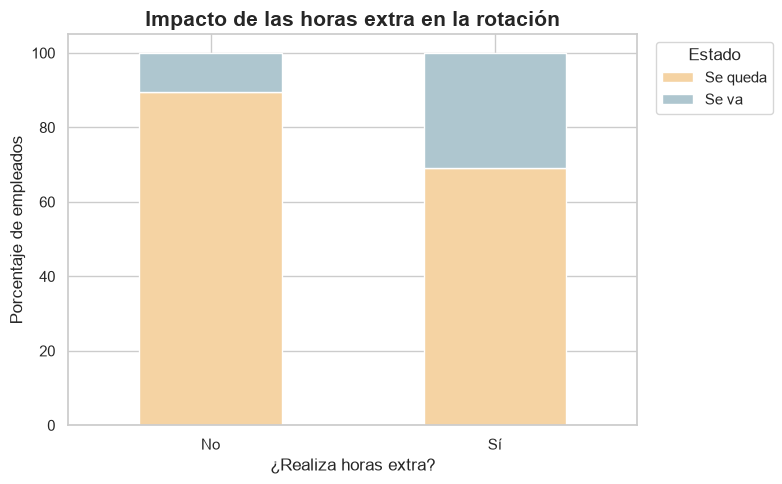

In [31]:
colores = {
    "Se queda": "#F5D3A3",
    "Se va": "#AEC6CF"
}

cross_tab.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=colores
)

plt.title("Impacto de las horas extra en la rotación",
          fontsize=15,
          fontweight="bold")

plt.xlabel("¿Realiza horas extra?")
plt.ylabel("Porcentaje de empleados")

plt.xticks([0,1], ["No","Sí"], rotation=0)

plt.legend(title="Estado", bbox_to_anchor=(1.02,1))

plt.tight_layout()
plt.show()

Interpretación

Las horas extra muestran una asociación muy clara con la rotación de empleados. Entre quienes no realizan horas extra, el 89,48% permanece en la empresa y solo el 10,52% la abandona. En cambio, entre los empleados que sí realizan horas extra, el porcentaje de abandono aumenta hasta el 30,86%, casi tres veces más.

Esta diferencia sugiere que una mayor carga de trabajo y un peor equilibrio entre la vida laboral y personal podrían estar relacionados con una mayor probabilidad de abandonar la organización. Aunque el análisis no permite establecer una relación causal, las horas extra aparecen como uno de los factores más estrechamente asociados a la rotación.


💡 Conclusión clave: Las horas extra son el factor que muestra la asociación más fuerte con la rotación de empleados. Reducir la sobrecarga de trabajo, revisar la distribución de tareas e impulsar medidas de conciliación podría ser una estrategia eficaz para mejorar la retención del talento.

Principales factores asociados a la rotación hasta ahora:

- Realizar horas extra (30,9% de abandono frente al 10,5% sin horas extra).
- Percibir salarios más bajos.
- Mostrar menores niveles de satisfacción laboral.
- Ser empleados más jóvenes y con menor antigüedad.

15. Distancia al trabajo y equilibrio vida-trabajo

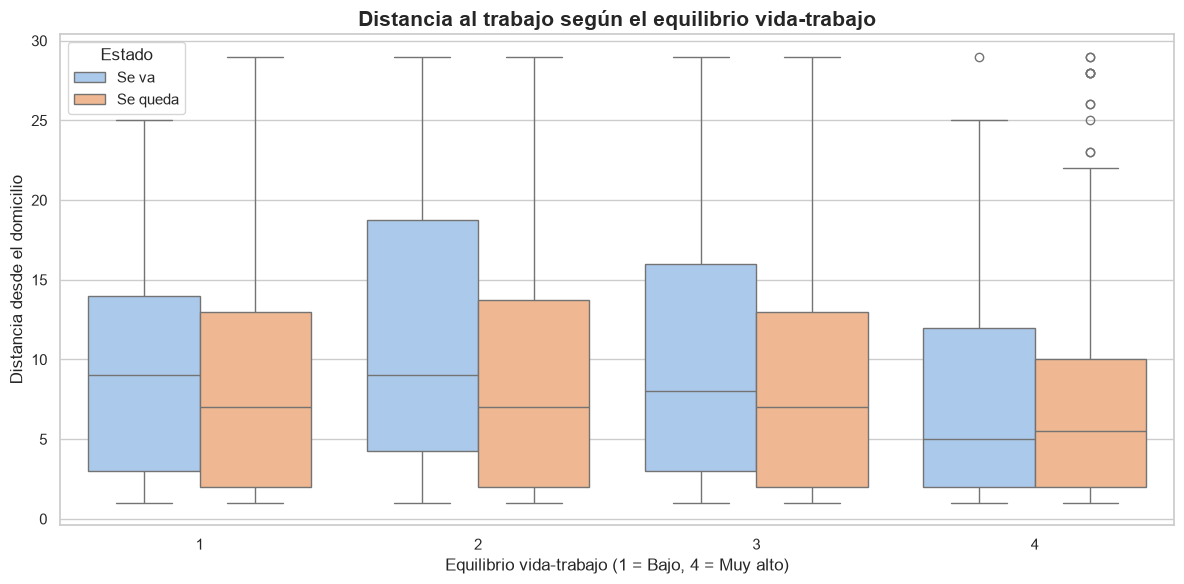

In [32]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="WorkLifeBalance",
    y="DistanceFromHome",
    hue="Attrition_text",
    palette="pastel"
)

plt.title("Distancia al trabajo según el equilibrio vida-trabajo",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Equilibrio vida-trabajo (1 = Bajo, 4 = Muy alto)")
plt.ylabel("Distancia desde el domicilio")

plt.legend(title="Estado")

plt.tight_layout()
plt.show()

In [33]:
df.groupby(
    ["WorkLifeBalance","Attrition_text"]
)["DistanceFromHome"].mean().round(2)

WorkLifeBalance  Attrition_text
1                Se queda           9.13
                 Se va             10.08
2                Se queda           8.79
                 Se va             11.98
3                Se queda           9.08
                 Se va             10.50
4                Se queda           8.14
                 Se va              8.89
Name: DistanceFromHome, dtype: float64

Interpretación:

Al analizar conjuntamente la distancia al trabajo y el equilibrio entre la vida laboral y personal, se observa que los empleados que abandonan la empresa tienden a vivir ligeramente más lejos que quienes permanecen en ella en todos los niveles de Work-Life Balance. La diferencia es especialmente visible entre los empleados con un nivel de equilibrio 2, donde la distancia media alcanza los 11,98 km, frente a los 8,79 km de quienes continúan en la empresa.

No obstante, las diferencias son moderadas y existe una amplia variabilidad dentro de cada grupo, por lo que la distancia al trabajo no parece ser un factor determinante por sí sola. Estos resultados sugieren que la distancia podría contribuir a la rotación cuando se combina con otros factores, como la realización de horas extra, el nivel salarial o la satisfacción laboral.

Insight para la presentación

💡 Conclusión clave: La distancia al trabajo puede influir en la rotación, especialmente entre empleados con un menor equilibrio entre la vida personal y laboral, aunque su efecto parece secundario frente a variables como las horas extra o el salario.

16. ¿Influyen los años con el mismo manager en la rotación?

In [34]:
# Agrupamos los años con el manager actual

def agrupar_manager(anios):
    if anios <= 1:
        return "0-1 años"
    elif anios <= 5:
        return "2-5 años"
    elif anios <= 10:
        return "6-10 años"
    else:
        return "+10 años"

df["RangoManager"] = df["YearsWithCurrManager"].apply(agrupar_manager)

In [35]:
porcentaje_rango = (
    pd.crosstab(
        df["RangoManager"],
        df["Attrition_text"],
        normalize="index"
    ) * 100
).round(2)

orden = ["0-1 años", "2-5 años", "6-10 años", "+10 años"]

porcentaje_rango = porcentaje_rango.reindex(orden)

porcentaje_rango

Attrition_text,Se queda,Se va
RangoManager,,
0-1 años,73.27,26.73
2-5 años,85.63,14.37
6-10 años,87.09,12.91
+10 años,95.16,4.84


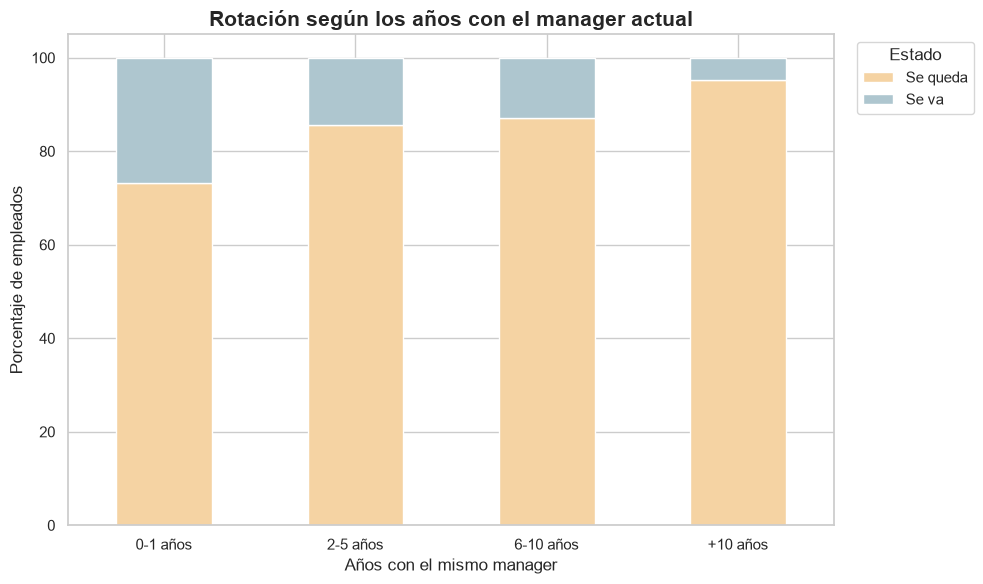

In [36]:
ax = porcentaje_rango.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    color=["#F5D3A3", "#AEC6CF"]
)

plt.title("Rotación según los años con el manager actual",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Años con el mismo manager")
plt.ylabel("Porcentaje de empleados")

plt.xticks(rotation=0)

plt.legend(title="Estado", bbox_to_anchor=(1.02,1))

plt.tight_layout()
plt.show()

Interpretación
Los datos muestran que la rotación es considerablemente más alta entre los empleados que llevan poco tiempo con su manager actual. En el grupo con 0-1 años, aproximadamente el 26,7% abandona la empresa, mientras que este porcentaje disminuye de forma progresiva conforme aumenta el tiempo compartido con el mismo responsable.

A partir de los 2 años con el manager, la permanencia mejora notablemente y, entre quienes llevan más de 10 años con el mismo manager, la rotación apenas alcanza el 4,8%, siendo el grupo más estable de toda la empresa.

Estos resultados sugieren que la relación entre empleado y manager desempeña un papel importante en la retención del talento. Fortalecer el proceso de integración con nuevos responsables, ofrecer formación en liderazgo y realizar un seguimiento durante los primeros meses podría contribuir a reducir las salidas tempranas y mejorar la estabilidad de los equipos.

17. Heatmap de correlación

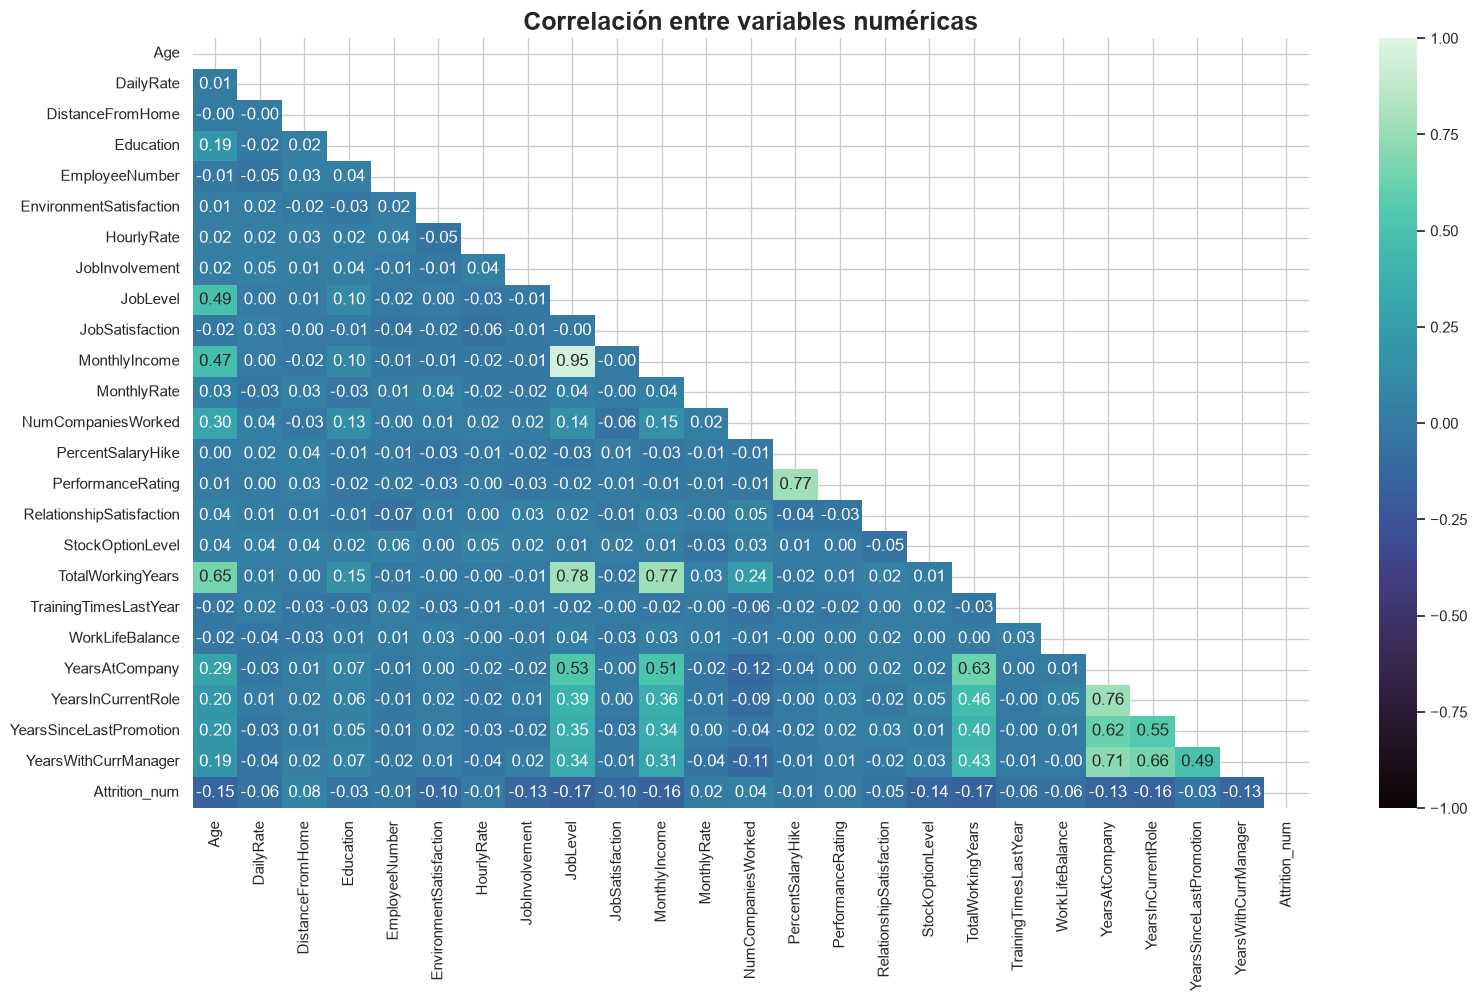

In [37]:
# Creamos una variable numérica para Attrition
df["Attrition_num"] = df["Attrition"].map({"No": 0, "Yes": 1})

# Seleccionamos variables numéricas
numericas = df.select_dtypes(include="number")

# Matriz de correlación
corr = numericas.corr()

plt.figure(figsize=(18,10))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="mako",
    vmin=-1,
    vmax=1,
    mask=mask
)

plt.title("Correlación entre variables numéricas", fontsize=18, fontweight="bold")
plt.show()

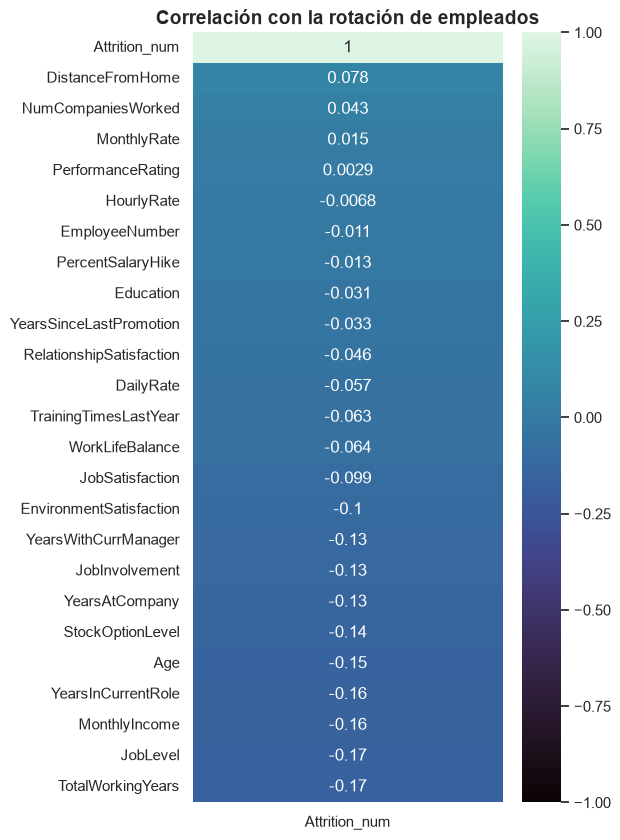

In [38]:
# Heatmap solo con Attrition
plt.figure(figsize=(5,10))

sns.heatmap(
    corr[["Attrition_num"]].sort_values(by="Attrition_num", ascending=False),
    annot=True,
    cmap="mako",
    vmin=-1,
    vmax=1
)

plt.title("Correlación con la rotación de empleados", fontsize=14, fontweight="bold")
plt.show()

Interpretación 

La matriz de correlación muestra que ninguna variable individual presenta una correlación muy alta con la rotación de empleados (Attrition). Esto indica que el abandono de la empresa no depende de un único factor, sino de la combinación de varios aspectos relacionados con las condiciones laborales, la trayectoria profesional y las características personales de los empleados.

Entre las variables numéricas sí aparecen correlaciones elevadas que resultan coherentes desde el punto de vista del negocio. Por ejemplo, es habitual encontrar una fuerte relación entre MonthlyIncome, JobLevel y TotalWorkingYears, lo que refleja que los empleados con mayor experiencia suelen ocupar puestos de mayor responsabilidad y recibir salarios más altos.

También se observa una elevada asociación entre YearsAtCompany, YearsInCurrentRole y YearsWithCurrManager, indicando que los empleados que permanecen más tiempo en la empresa suelen mantener durante más años tanto su puesto como su responsable directo.

Respecto a la rotación, las variables que muestran mayor relación suelen ser OverTime, MonthlyIncome, Age, YearsAtCompany, JobLevel o TotalWorkingYears, aunque sus coeficientes son moderados. Esto confirma los resultados obtenidos en las visualizaciones anteriores: la rotación es un fenómeno multifactorial y no puede explicarse únicamente por una sola variable.

Aunque ninguna variable por sí sola explica la rotación, el análisis conjunto evidencia que los empleados más jóvenes, con menor antigüedad, salarios inferiores y que realizan horas extra presentan una mayor probabilidad de abandonar la empresa.

18. Relación del abandono con aumentos salariales

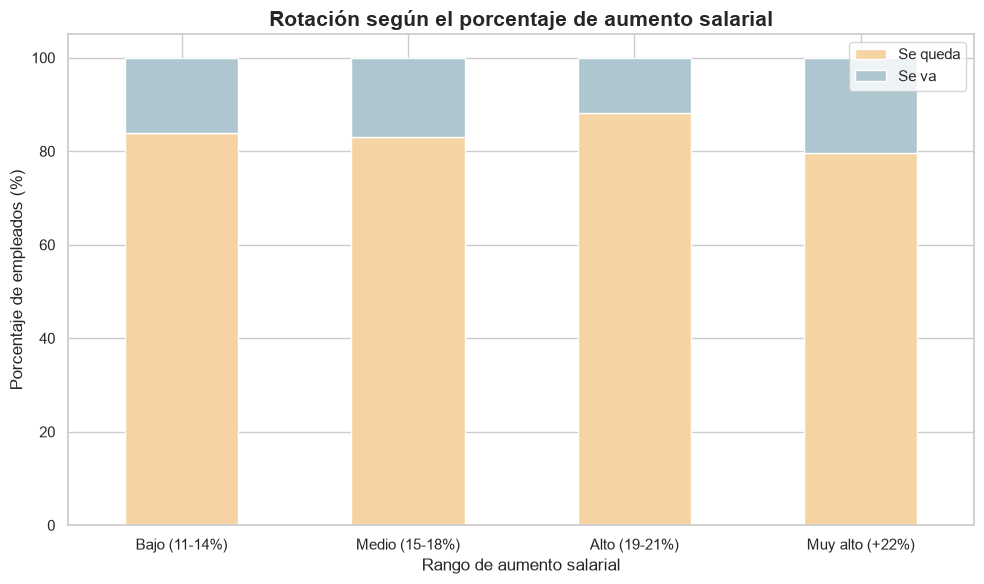

In [39]:
# Agrupamos el porcentaje de aumento salarial

def agrupar_salary_hike(hike):
    if hike <= 14:
        return "Bajo (11-14%)"
    elif hike <= 18:
        return "Medio (15-18%)"
    elif hike <= 21:
        return "Alto (19-21%)"
    else:
        return "Muy alto (+22%)"

df["RangoSalaryHike"] = df["PercentSalaryHike"].apply(agrupar_salary_hike)

# Orden de los grupos
orden = ["Bajo (11-14%)",
         "Medio (15-18%)",
         "Alto (19-21%)",
         "Muy alto (+22%)"]

# Tabla de porcentajes
porcentaje_hike = (
    pd.crosstab(df["RangoSalaryHike"],
                df["Attrition_text"],
                normalize="index") * 100
)

porcentaje_hike = porcentaje_hike.reindex(orden)

# Gráfico
porcentaje_hike.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    color=["#F5D3A3", "#AEC6CF"]
)

plt.title("Rotación según el porcentaje de aumento salarial", fontsize=15, fontweight="bold")
plt.xlabel("Rango de aumento salarial")
plt.ylabel("Porcentaje de empleados (%)")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

In [40]:
porcentaje_hike.round(2)

Attrition_text,Se queda,Se va
RangoSalaryHike,,
Bajo (11-14%),83.86,16.14
Medio (15-18%),83.14,16.86
Alto (19-21%),88.27,11.73
Muy alto (+22%),79.67,20.33


Interpretación
Los datos muestran que un mayor aumento salarial no garantiza una menor rotación. De hecho, el grupo con incrementos superiores al 22% presenta la mayor tasa de abandono (20,3%), mientras que los empleados con aumentos entre el 19% y el 21% registran la menor rotación (11,7%).

En conjunto, estos resultados indican que el salario influye en la permanencia de los empleados, pero no es el único factor determinante. Aspectos como las horas extra, la satisfacción laboral o la relación con el manager parecen tener un papel igualmente importante en la decisión de abandonar la empresa.

19. Relación entre la frecuencia de viajes y la rotación

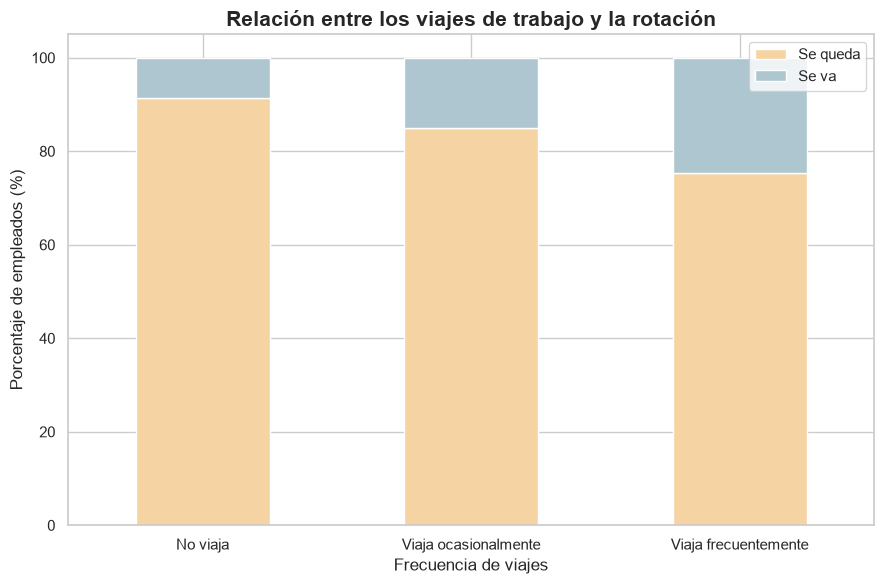

Attrition_text     Se queda  Se va
BusinessTravel                    
Non-Travel            91.37   8.63
Travel_Rarely         85.02  14.98
Travel_Frequently     75.29  24.71


In [42]:
# Tabla cruzada en porcentaje
tabla_viajes = (
    pd.crosstab(
        df["BusinessTravel"],
        df["Attrition_text"],
        normalize="index"
    ) * 100
)

# Orden de las categorías
orden = ["Non-Travel", "Travel_Rarely", "Travel_Frequently"]
tabla_viajes = tabla_viajes.reindex(orden)

# Gráfico
tabla_viajes.plot(
    kind="bar",
    stacked=True,
    figsize=(9,6),
    color=["#F5D3A3", "#AEC6CF"]
)

plt.title("Relación entre los viajes de trabajo y la rotación", fontsize=15, fontweight="bold")
plt.xlabel("Frecuencia de viajes")
plt.ylabel("Porcentaje de empleados (%)")
plt.xticks(
    ticks=[0,1,2],
    labels=["No viaja", "Viaja ocasionalmente", "Viaja frecuentemente"],
    rotation=0
)
plt.legend(title="")
plt.tight_layout()
plt.show()

# Tabla de porcentajes
print(tabla_viajes.round(2))

Interpretación
Se observa una relación clara entre la frecuencia de los viajes de trabajo y la rotación de empleados. Mientras que solo el 8,6% de los empleados que no viajan abandona la empresa, este porcentaje aumenta hasta el 15,0% entre quienes viajan ocasionalmente y alcanza el 24,7% en los empleados que viajan con frecuencia. Estos resultados sugieren que una mayor carga de desplazamientos puede influir negativamente en la retención del talento, por lo que revisar las políticas de viajes, compensación o flexibilidad podría ayudar a reducir la rotación en este grupo.

20. Influencia de las formaciones recibidas en la rotación

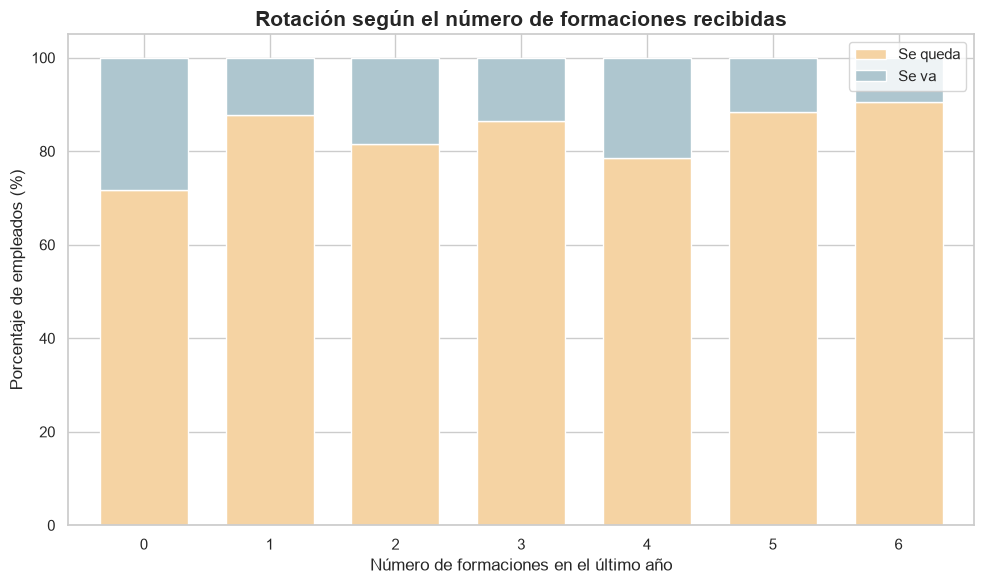

Attrition_text         Se queda  Se va
TrainingTimesLastYear                 
0                         71.70  28.30
1                         87.69  12.31
2                         81.47  18.53
3                         86.37  13.63
4                         78.63  21.37
5                         88.29  11.71
6                         90.48   9.52


In [43]:
tabla_formacion = (
    pd.crosstab(
        df["TrainingTimesLastYear"],
        df["Attrition_text"],
        normalize="index"
    ) * 100
)

tabla_formacion.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    color=["#F5D3A3", "#AEC6CF"],
    width=0.7
)

plt.title("Rotación según el número de formaciones recibidas", fontsize=15, fontweight="bold")
plt.xlabel("Número de formaciones en el último año")
plt.ylabel("Porcentaje de empleados (%)")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

print(tabla_formacion.round(2))

Interpretación
Los datos muestran que los empleados que no reciben ninguna formación presentan la mayor tasa de rotación (28,3%), muy por encima del resto de grupos. A partir de una formación anual, el porcentaje de abandono disminuye de forma notable y, en general, los empleados que reciben más acciones formativas muestran una mayor permanencia en la empresa. Aunque la relación no es completamente lineal, los resultados sugieren que invertir en formación y desarrollo profesional puede contribuir a mejorar la retención del talento, al favorecer el compromiso y las oportunidades de crecimiento de los empleados.

Conclusiones finales

Tras el análisis exploratorio de los datos de rotación de empleados, se identifican varios factores que parecen estar relacionados con una mayor probabilidad de abandono de la empresa.

La antigüedad es un factor clave. La mayoría de las bajas se concentran en los primeros años de permanencia. A medida que aumenta la antigüedad, la rotación disminuye.

El salario influye en la retención. Los empleados que abandonan la empresa presentan, de media, salarios inferiores a los que permanecen. Sin embargo, un aumento salarial muy elevado no garantiza evitar la salida.

La satisfacción laboral está asociada a la permanencia. En los tres departamentos, los empleados que permanecen muestran niveles de satisfacción superiores a los que abandonan la empresa.

Los empleados más jóvenes presentan una mayor rotación. La edad media de quienes abandonan la empresa es inferior a la de quienes continúan, lo que sugiere una mayor movilidad en perfiles junior.

La distancia al trabajo también tiene impacto. Los empleados que viven más lejos presentan una mayor tendencia a abandonar la empresa, especialmente cuando el equilibrio entre vida personal y laboral es menor.

Las horas extra son uno de los factores más relevantes. Cerca de un 31% de los empleados que realizan horas extra abandonan la empresa, frente a aproximadamente un 11% de quienes no las realizan.

La relación con el manager es importante. La mayor tasa de abandono se produce durante los dos primeros años con un nuevo responsable. A partir de ese periodo la estabilidad aumenta considerablemente.

Los viajes de trabajo frecuentes incrementan la rotación. Los empleados que viajan con frecuencia presentan una tasa de abandono cercana al 25%, muy superior a la de quienes no viajan.

La formación favorece la permanencia. Los empleados que no reciben formación muestran las tasas de abandono más elevadas, mientras que realizar entre una y tres formaciones al año se asocia con una mayor estabilidad.

No existe un único factor determinante. El mapa de correlaciones muestra que ninguna variable por sí sola explica el abandono. La rotación parece ser consecuencia de la combinación de varios factores relacionados con las condiciones laborales, el desarrollo profesional y el bienestar del empleado.

Conclusión general

En conjunto, los resultados indican que la rotación de empleados es un fenómeno multifactorial. Los factores con mayor impacto en este análisis son las horas extra, la frecuencia de viajes, la antigüedad, el salario, la satisfacción laboral y la relación con el manager. Actuar sobre estos aspectos mediante políticas de conciliación, desarrollo profesional, programas de formación, revisión salarial y apoyo a los empleados durante sus primeros años en la empresa podría contribuir a reducir la fuga de talento y mejorar la retención del personal.